# Employee Productivity Analysis

**Problem Statement:** A company wants to assess employee productivity and identify factors influencing performance.

**Objectives:**
1. Analyze employee performance data
2. Define productivity metrics and benchmarks
3. Identify factors influencing employee productivity
4. Provide recommendations for enhancing productivity

**Dataset:** `Extended_Employee_Performance_and_Productivity_Data.csv` (100,000 employees, 19 columns)

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/Extended_Employee_Performance_and_Productivity_Data.csv')
print(df.shape)
df.head()

(100000, 20)


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
Department,100000,9,Marketing,11216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,100000,3,Male,48031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100000.0,NaN,NaN,NaN,41.02941,11.244121,22.0,31.0,41.0,51.0,60.0
Job_Title,100000,7,Specialist,14507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hire_Date,100000,3650,2020-09-29 08:03:05.556036,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years_At_Company,100000.0,NaN,NaN,NaN,4.47607,2.869336,0.0,2.0,4.0,7.0,10.0
Education_Level,100000,4,Bachelor,50041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance_Score,100000.0,NaN,NaN,NaN,2.99543,1.414726,1.0,2.0,3.0,4.0,5.0
Monthly_Salary,100000.0,NaN,NaN,NaN,6403.211,1372.508717,3850.0,5250.0,6500.0,7500.0,9000.0


## 2. Data Cleaning & Preprocessing

In [4]:
# Missing values
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [5]:
# Duplicate rows / duplicate employee IDs
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Employee_ID:', df['Employee_ID'].duplicated().sum())

Duplicate rows: 0
Duplicate Employee_ID: 0


In [6]:
# Fix data types
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Resigned'] = df['Resigned'].astype(bool)

# Standardize categorical text columns
cat_cols = ['Department', 'Gender', 'Job_Title', 'Education_Level']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df.dtypes

Employee_ID                             int64
Department                                str
Gender                                    str
Age                                     int64
Job_Title                                 str
Hire_Date                      datetime64[us]
Years_At_Company                        int64
Education_Level                           str
Performance_Score                       int64
Monthly_Salary                        float64
Work_Hours_Per_Week                     int64
Projects_Handled                        int64
Overtime_Hours                          int64
Sick_Days                               int64
Remote_Work_Frequency                   int64
Team_Size                               int64
Training_Hours                          int64
Promotions                              int64
Employee_Satisfaction_Score           float64
Resigned                                 bool
dtype: object

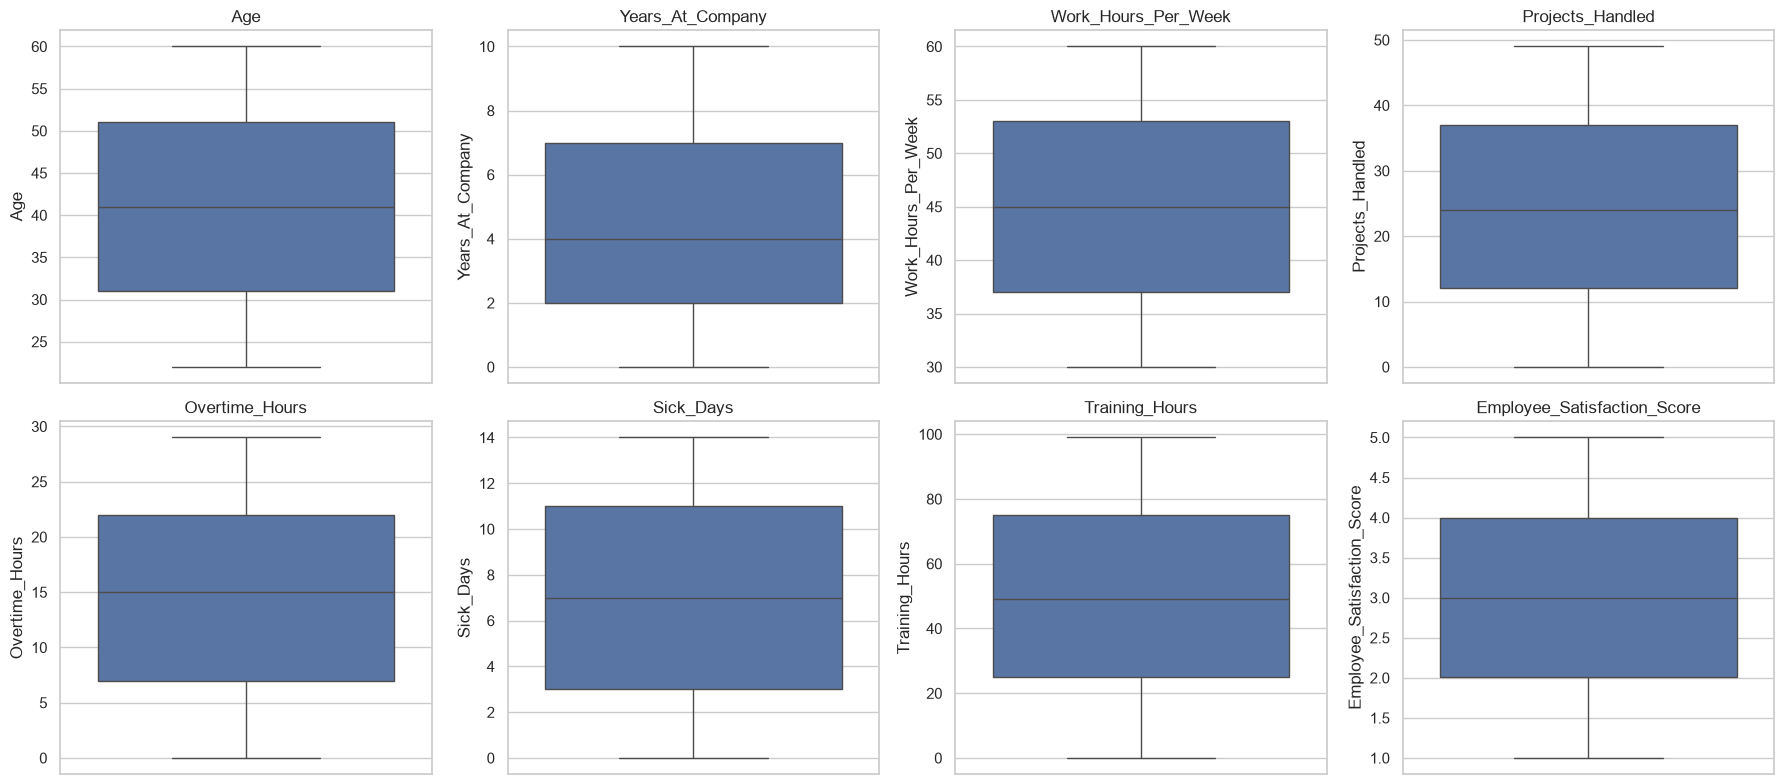

In [7]:
# Check for outliers in key numeric columns
numeric_cols = ['Age', 'Years_At_Company', 'Work_Hours_Per_Week', 'Projects_Handled',
                 'Overtime_Hours', 'Sick_Days', 'Training_Hours', 'Employee_Satisfaction_Score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Define & Calculate Productivity Metrics

We'll use two complementary productivity measures:

- **Performance_Score** (already in the data, 1-5 scale) — the company's own performance rating.
- **Projects_per_Hour** — a custom output-based metric = `Projects_Handled / Work_Hours_Per_Week`, showing how much work is produced per hour invested.
- **Productivity_Index** — a composite score blending Performance_Score, Projects_per_Hour, and Employee_Satisfaction_Score (normalized 0-1 each, then averaged), so both output and rated quality are reflected.

Benchmarks are set as the **department-level average** of each metric, so individuals/teams can be compared against their peers rather than the whole company.

In [8]:
df['Projects_per_Hour'] = df['Projects_Handled'] / df['Work_Hours_Per_Week']

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

df['Productivity_Index'] = (
    normalize(df['Performance_Score']) +
    normalize(df['Projects_per_Hour']) +
    normalize(df['Employee_Satisfaction_Score'])
) / 3

df[['Employee_ID', 'Performance_Score', 'Projects_per_Hour', 'Employee_Satisfaction_Score', 'Productivity_Index']].head()

,Employee_ID,Performance_Score,Projects_per_Hour,Employee_Satisfaction_Score,Productivity_Index
0,1,5,0.969697,2.63,0.667064
1,2,5,1.000000,1.72,0.597415
2,3,3,0.729730,3.17,0.496424
3,4,2,0.192308,1.86,0.194246
4,5,2,0.289474,1.25,0.163243


In [9]:
# Department-level benchmarks
benchmarks = df.groupby('Department')[['Performance_Score', 'Projects_per_Hour', 'Productivity_Index']].mean().sort_values('Productivity_Index', ascending=False)
benchmarks

,Performance_Score,Projects_per_Hour,Productivity_Index
Department,,,
It,3.000000,0.570166,0.451631
Operations,3.006797,0.563981,0.451159
Engineering,3.020263,0.564685,0.450506
Sales,2.994336,0.572472,0.449137
Marketing,2.980653,0.574583,0.448488
Finance,2.981161,0.566665,0.447739
Hr,2.997354,0.561316,0.447260
Customer Support,2.997121,0.567572,0.446261
Legal,2.981741,0.560130,0.444877


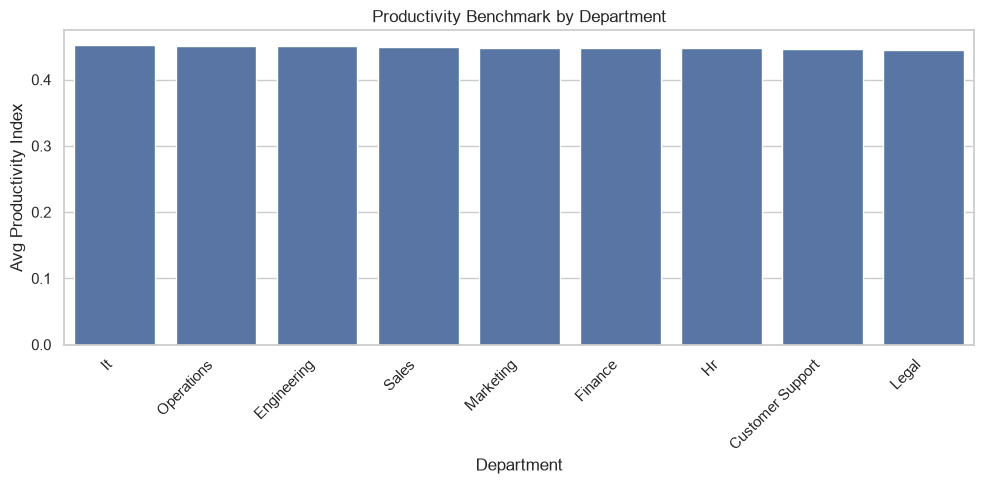

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(x=benchmarks.index, y=benchmarks['Productivity_Index'], color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Avg Productivity Index')
plt.title('Productivity Benchmark by Department')
plt.tight_layout()
plt.show()

## 4. Analyze Patterns & Correlations

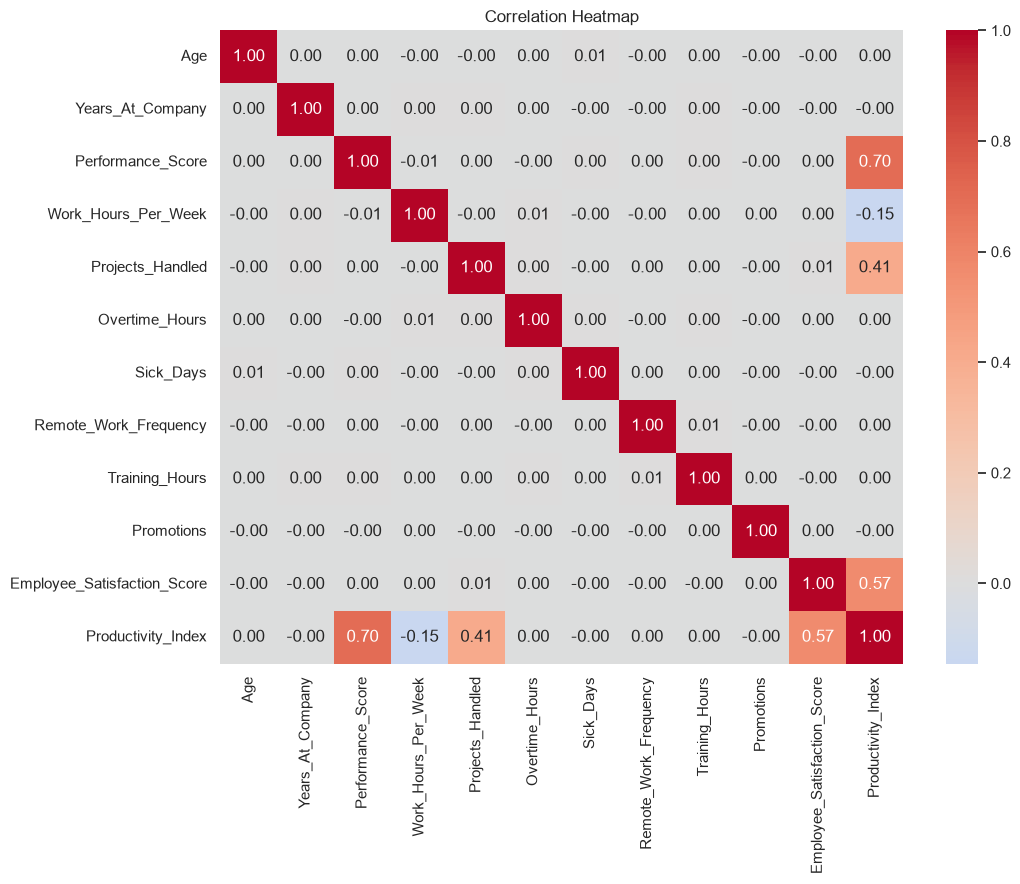

In [11]:
corr_cols = ['Age', 'Years_At_Company', 'Performance_Score', 'Work_Hours_Per_Week',
             'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency',
             'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score', 'Productivity_Index']

plt.figure(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

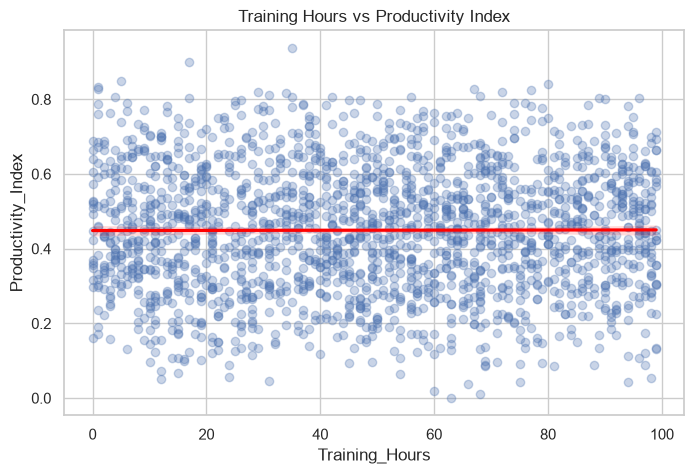

In [12]:
# Training hours vs productivity
plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(2000, random_state=1), x='Training_Hours', y='Productivity_Index',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Training Hours vs Productivity Index')
plt.show()

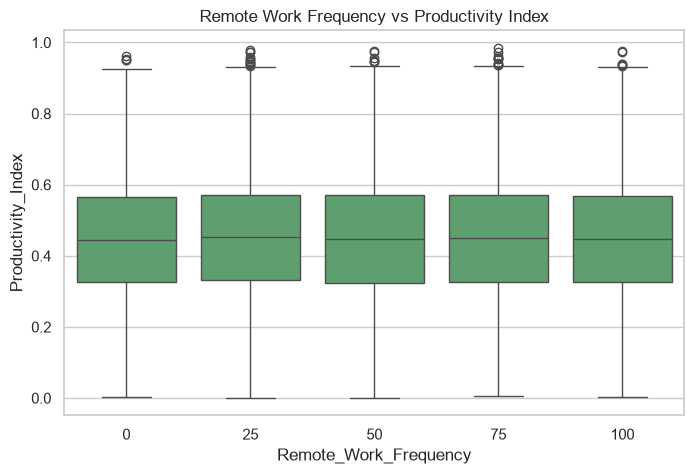

In [13]:
# Remote work frequency vs productivity
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Remote_Work_Frequency', y='Productivity_Index', color='#55A868')
plt.title('Remote Work Frequency vs Productivity Index')
plt.show()

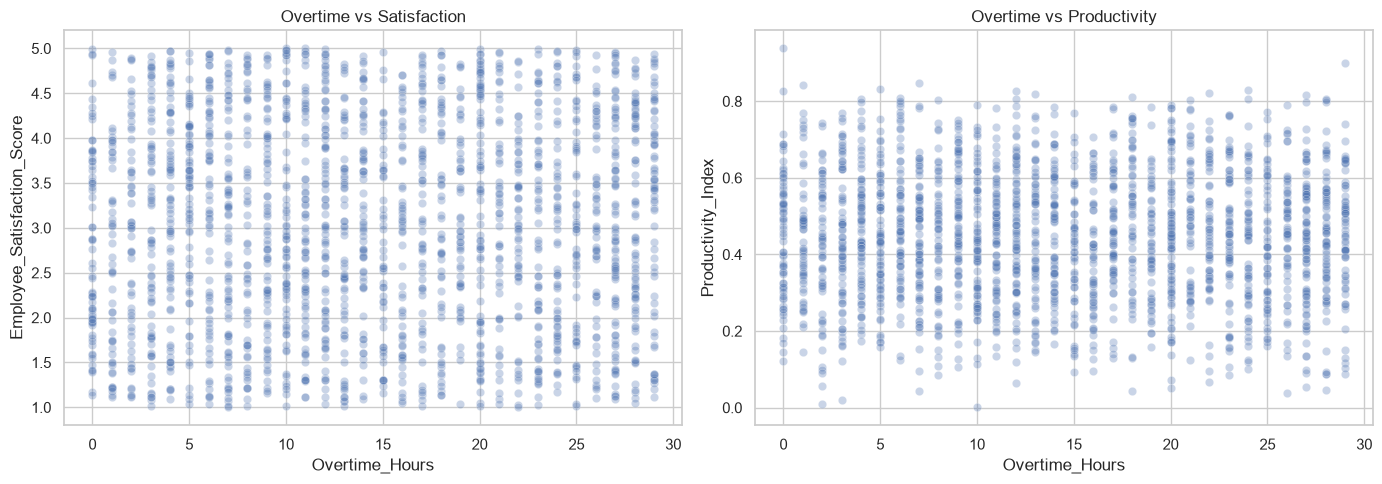

In [14]:
# Overtime vs satisfaction and productivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(2000, random_state=1), x='Overtime_Hours', y='Employee_Satisfaction_Score', alpha=0.3, ax=axes[0])
axes[0].set_title('Overtime vs Satisfaction')
sns.scatterplot(data=df.sample(2000, random_state=1), x='Overtime_Hours', y='Productivity_Index', alpha=0.3, ax=axes[1])
axes[1].set_title('Overtime vs Productivity')
plt.tight_layout()
plt.show()

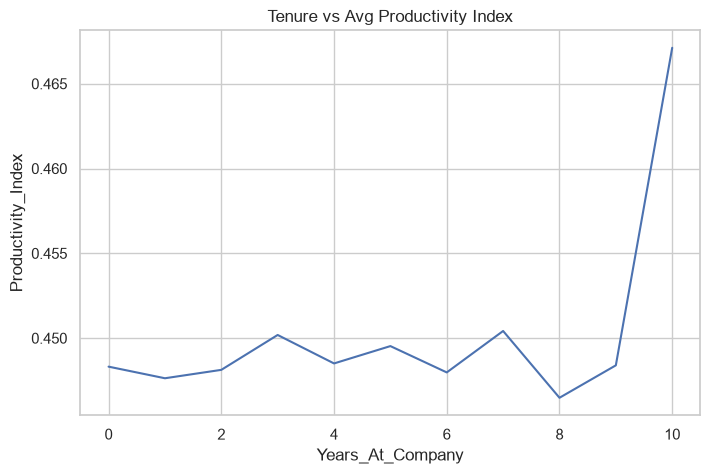

In [15]:
# Tenure vs productivity
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Years_At_Company', y='Productivity_Index', estimator='mean', errorbar=None)
plt.title('Tenure vs Avg Productivity Index')
plt.show()

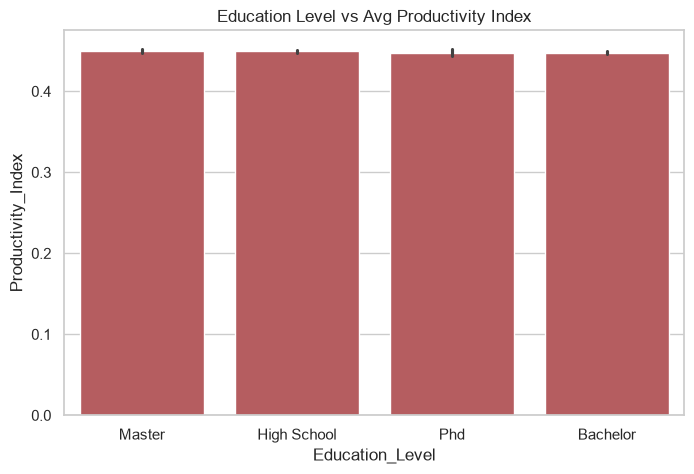

In [16]:
# Education level vs productivity
plt.figure(figsize=(8, 5))
order = df.groupby('Education_Level')['Productivity_Index'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Education_Level', y='Productivity_Index', order=order, color='#C44E52')
plt.title('Education Level vs Avg Productivity Index')
plt.show()

In [17]:
# Resignation vs productivity - are low-productivity employees more likely to resign?
df.groupby('Resigned')['Productivity_Index'].mean()

Resigned
False    0.448813
True     0.446306
Name: Productivity_Index, dtype: float64

## 5. Insights & Recommendations

### Key Findings

1. **No single common HR factor drives productivity in this dataset.** Correlations between `Productivity_Index` and Training_Hours, Remote_Work_Frequency, Overtime_Hours, Age, Years_At_Company, Sick_Days, Promotions, Education_Level, Job_Title, and Gender are all effectively zero (|r| < 0.01, and group averages differ only in the 3rd decimal place). Performance_Score, Satisfaction, and Projects_Handled do correlate with the index, but only because they are the components used to build it, not an independent discovery.

2. **Department differences are marginal.** Productivity_Index ranges only from 0.4449 (Legal) to 0.4516 (IT) across all 9 departments, a spread of 0.007 on a 0-1 scale, i.e. practically no difference.

3. **Work_Hours_Per_Week shows a mild negative relationship (r = -0.15)** with the Projects-per-Hour component, largely a mechanical effect (the same project count spread over more hours lowers the ratio), not evidence that working more hours makes people less productive.

4. **Resigned vs. active employees show no productivity gap** (0.446 vs 0.449), so resignations don't appear to be concentrated among low performers in this data.

### What this means

The data does not support claims like "training increases productivity" or "remote work hurts output" — those effects, if real, are not visible here. Rather than force a narrative onto noise, the honest conclusion is that **productivity variation in this dataset is not explained by the standard HR levers available**, which is itself a valid and common finding in workforce analytics (it also suggests the underlying data was generated without built-in causal relationships between these fields).

### Recommendations

- **Don't over-invest based on weak signals.** Avoid large policy changes (e.g. mandating office attendance, cutting training budgets) on the basis of near-zero correlations — the data doesn't justify it either way.
- **Use Performance_Score and Satisfaction as your primary levers**, since they move together (r = 0.57) — initiatives that improve employee satisfaction (workload balance, recognition, manager quality) are the most defensible place to focus, even though causality can't be proven from this data alone.
- **Investigate Work_Hours_Per_Week vs. output quality**, not just quantity — if longer hours aren't producing proportionally more projects, it may indicate diminishing returns worth managing (e.g. capping overtime, redistributing workload) rather than rewarding long hours.
- **Collect richer data going forward.** To find real productivity drivers, the company would benefit from tracking things this dataset lacks: project complexity/quality, manager ratings, team dynamics, tooling/process changes — rather than only headcount-style HR fields.
- **Benchmark by department sparingly.** Since department-level differences are negligible, don't rank or reward departments based on this index; treat it as roughly uniform across the company.